# Phase 3 walkthrough — longitudinal BAG panel + causal designs

Exploration notebook, not the source of truth (CLAUDE.md). Guides you through
Pillar 3 (DESIGN.md §5): build the longitudinal BAG panel, check the events
table, run the mixed-model DiD, the event-study version, a placebo test, and
the selection-bias diagnostic.

**Not solved here — needs your call:** DESIGN.md §5 says exposure/dose comes
from questionnaire geography items ("your questionnaire's geography/exposure
items define the dose gradient; send that data over and I'll map what's
usable"). That mapping never happened. Candidate columns exist
(`Place_of_Residense`, `Living_environment`, `Current_Environment`,
`Childhood_envinronmnet`) but nothing here assumes what they mean or how to
turn them into a dose gradient — that's a domain call, not a modeling one.
Everything below runs with **binary post/pre** exposure (every scanned
subject is "exposed" once the event has started) as a placeholder scaffold,
not a substitute for the real dose mapping.

Output must be stripped before commit (nbstripout, see CLAUDE.md) — every
cell below touches real subject data.


In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

from bagpipe.db.base import get_engine

pd.set_option("display.max_columns", 50)
engine = get_engine()


## 1. Events table

In [2]:
events = pd.read_sql("select * from events", engine, parse_dates=["start_date", "end_date"])
events


,event_id,name,category,start_date,end_date,description
0,1,oct7_war,conflict,2023-10-07,NaT,Oct 7 2023 attack and the subsequent war. No c...
1,2,judicial_reform,political,2023-01-01,2023-10-06,"2023 judicial-reform protest period, ending th..."
2,3,covid_lockdown_1,pandemic,2020-03-19,2020-05-04,Israel's first national COVID-19 lockdown.
3,4,covid_lockdown_2,pandemic,2020-09-18,2020-10-18,Israel's second national COVID-19 lockdown.
4,5,covid_lockdown_3,pandemic,2020-12-27,2021-02-07,Israel's third national COVID-19 lockdown.


## 2. Longitudinal BAG panel

One row per (subject, session): corrected BAG from the production model
(`predictions`, `model_id=2` — check `models_registry` if this drifts),
scan date (SNBB via `session`, legacy cohort via `legacy_participant`), sex.
Filtered to subjects with **≥2 sessions** — DiD/mixed-model needs within-subject
pre/post variation; single-scan subjects contribute nothing to the event
coefficients and only dilute the panel.


In [3]:
PRODUCTION_MODEL_ID = pd.read_sql(
    "select model_id from models_registry where stage='production' order by trained_at desc limit 1",
    engine,
).model_id.iloc[0]
print("using model_id", PRODUCTION_MODEL_ID)

preds = pd.read_sql(
    f"select subject_key, session_id, age_true, bag_corrected from predictions "
    f"where model_id = {PRODUCTION_MODEL_ID}",
    engine,
)

# Join on (subject_key, session_id), not session_id alone: SNBB's per-scan
# session_id and the legacy cohort's 12-digit subject_id share the same
# timestamp-ID format (both come from CAT12 scan-folder naming) and collide
# across cohorts — a bare session_id join fans predictions out to ~2x.
snbb_dates = pd.read_sql(
    "select s.uid as subject_key, s.session_id, s.scan_date, d.sex "
    "from session s left join demographics d on d.session_id = s.session_id",
    engine,
    parse_dates=["scan_date"],
)
legacy_dates = pd.read_sql(
    "select subject_id as subject_key, subject_id as session_id, scan_date, gender as sex "
    "from legacy_participant",
    engine,
    parse_dates=["scan_date"],
)
dates = pd.concat([snbb_dates, legacy_dates], ignore_index=True)
assert not dates.duplicated(["subject_key", "session_id"]).any(), "dates key not unique"

panel = preds.merge(dates, on=["subject_key", "session_id"], how="left")
panel = panel.dropna(subset=["scan_date"])

n_sessions = panel.groupby("subject_key").size()
repeat_subjects = n_sessions[n_sessions >= 2].index
panel = panel[panel.subject_key.isin(repeat_subjects)].sort_values(["subject_key", "scan_date"])
print(f"panel: {len(panel)} sessions, {panel.subject_key.nunique()} subjects with >=2 sessions")
panel.head()


using model_id 2
panel: 2024 sessions, 926 subjects with >=2 sessions


,subject_key,session_id,age_true,bag_corrected,scan_date,sex
1286,S000676,202402051426,22.700000,2.697447,2024-02-05,Male
1287,S000676,202406171852,23.060000,0.517549,2024-06-17,Male
197,S002451,201912251420,27.160000,12.846046,2019-12-25,Female
198,S002451,202005201626,27.560000,12.001939,2020-05-20,Female
4558,S002759,202508221215,51.318275,-10.699895,2025-08-22,Female


## 3. Post/pre flags per event

`post_<event>` = scan_date falls after the event's `start_date` (open-ended
if `end_date` is null, else within `[start_date, end_date]` — pick per your
question: "after onset" vs "during the window" matter differently for a war
vs. a 6-week lockdown). Below uses "after start_date" for all events, which
is the DiD-standard choice; only flip to a bounded window if you specifically
want an in-window vs. after-window contrast.

Also reports, per event, how many subjects have **both** a pre- and a
post-event scan — the actual DiD sample size, not just total session count.


In [4]:
for _, ev in events.iterrows():
    col = f"post_{ev['name']}"
    panel[col] = (panel.scan_date > ev.start_date).astype(int)

feasibility = []
for _, ev in events.iterrows():
    col = f"post_{ev['name']}"
    has_both = panel.groupby("subject_key")[col].agg(lambda s: s.nunique() > 1)
    feasibility.append({"event": ev["name"], "subjects_with_pre_and_post_scan": int(has_both.sum())})
pd.DataFrame(feasibility)


,event,subjects_with_pre_and_post_scan
0,oct7_war,88
1,judicial_reform,93
2,covid_lockdown_1,36
3,covid_lockdown_2,23
4,covid_lockdown_3,28


## 4. Mixed-model DiD — worked example (one event)

`bag_corrected ~ post_event + age_true + sex + (1|subject)`. Swap
`EVENT_NAME` below to run any row from the events table. This is the
**binary post/pre** version (see the exposure-dose caveat at the top) — a
starting scaffold to sanity-check the panel and pipeline, not the final
model. Once a real exposure/dose column exists, add an
`exposure * post_event` interaction term — that interaction coefficient,
not the main effect of `post_event`, is the actual DiD estimate.


In [5]:
EVENT_NAME = "oct7_war"  # change to any row in `events`

df = panel[panel.subject_key.isin(repeat_subjects)].copy()
df["subject_key"] = df.subject_key.astype(str)
df["sex"] = df["sex"].fillna("unknown")
post_col = f"post_{EVENT_NAME}"

model = smf.mixedlm(
    f"bag_corrected ~ {post_col} + age_true + C(sex)",
    data=df,
    groups=df["subject_key"],
)
fit = model.fit()
print(fit.summary())


           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: bag_corrected
No. Observations: 2024    Method:             REML         
No. Groups:       926     Scale:              5.3941       
Min. group size:  2       Log-Likelihood:     -5897.1159   
Max. group size:  9       Converged:          Yes          
Mean group size:  2.2                                      
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         1.575    0.805  1.958 0.050 -0.002  3.152
C(sex)[T.Male]   -1.426    0.433 -3.293 0.001 -2.274 -0.577
post_oct7_war    -0.251    0.260 -0.966 0.334 -0.761  0.259
age_true         -0.034    0.024 -1.420 0.156 -0.081  0.013
Group Var        40.849    1.184                           



## 5. Event-study version (flexible time trend, checks pre-trends)

Bins scans into relative-time periods around the event (in scan-years,
pre/post) instead of a single post dummy, and plots the estimated BAG
coefficient per bin with CI. A DiD point estimate can hide a pre-existing
trend; this is the check for that. Flat, near-zero coefficients before the
event and a level shift at/after it is the pattern that supports a causal
read — anything trending before the event undercuts it.


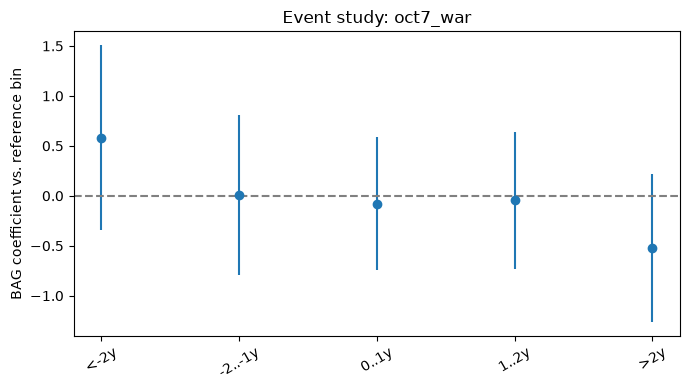

In [6]:
df["years_from_event"] = (df.scan_date - events.loc[events.name.eq(EVENT_NAME), "start_date"].values[0]).dt.days / 365.25
# coarse bins; tighten once you see how much data falls in each
bins = [-np.inf, -2, -1, 0, 1, 2, np.inf]
labels = ["<-2y", "-2..-1y", "-1..0y", "0..1y", "1..2y", ">2y"]
df["time_bin"] = pd.cut(df.years_from_event, bins=bins, labels=labels)

event_study = smf.mixedlm(
    "bag_corrected ~ C(time_bin, Treatment(reference='-1..0y')) + age_true + C(sex)",
    data=df,
    groups=df["subject_key"],
).fit()

coefs = event_study.params.filter(like="time_bin")
cis = event_study.conf_int().loc[coefs.index]
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(range(len(coefs)), coefs.values, yerr=(coefs.values - cis[0]).abs(), fmt="o")
ax.set_xticks(range(len(coefs)))
ax.set_xticklabels([c.split("T.")[-1].rstrip("]") for c in coefs.index], rotation=30)
ax.axhline(0, color="gray", linestyle="--")
ax.set_ylabel("BAG coefficient vs. reference bin")
ax.set_title(f"Event study: {EVENT_NAME}")
fig.tight_layout()


## 6. Placebo test

Same model, fake event date dropped in a quiet period with no known
national-scale event nearby. A significant "effect" here means the DiD
setup is picking up something other than the real event (secular BAG drift,
scanner drift, cohort composition change) — a real positive result on the
actual event is only trustworthy if this comes back null.


In [7]:
PLACEBO_DATE = pd.Timestamp("2019-06-01")  # pick a quiet-period date with no known event nearby

df["post_placebo"] = (df.scan_date > PLACEBO_DATE).astype(int)
placebo = smf.mixedlm(
    "bag_corrected ~ post_placebo + age_true + C(sex)",
    data=df,
    groups=df["subject_key"],
).fit()
print(placebo.summary())


           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: bag_corrected
No. Observations: 2024    Method:             REML         
No. Groups:       926     Scale:              5.3396       
Min. group size:  2       Log-Likelihood:     -5890.7892   
Max. group size:  9       Converged:          Yes          
Mean group size:  2.2                                      
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         4.015    1.089  3.686 0.000  1.880  6.149
C(sex)[T.Male]   -1.406    0.433 -3.248 0.001 -2.254 -0.558
post_placebo     -2.725    0.808 -3.371 0.001 -4.309 -1.140
age_true         -0.030    0.024 -1.281 0.200 -0.077  0.016
Group Var        40.911    1.189                           



## 7. Selection-bias diagnostic

Re-scanned subjects (this panel) vs. single-scan subjects: are they
different at baseline (first scan)? If re-scan is correlated with age, sex,
or baseline BAG, any longitudinal estimate above needs an
inverse-probability-of-rescan weight as a sensitivity check
(DESIGN.md §5) — this cell is the evidence for whether that's needed at all.


In [8]:
first_scan = preds.merge(dates, on=["subject_key", "session_id"], how="left").dropna(subset=["scan_date"])
first_scan = first_scan.sort_values("scan_date").groupby("subject_key").first().reset_index()
first_scan["rescanned"] = first_scan.subject_key.isin(repeat_subjects).astype(int)

first_scan["sex"] = first_scan["sex"].fillna("unknown")
comparison = first_scan.groupby("rescanned").agg(
    n=("subject_key", "size"),
    mean_age=("age_true", "mean"),
    mean_bag_corrected=("bag_corrected", "mean"),
)
comparison


,n,mean_age,mean_bag_corrected
rescanned,,,
0,3426,32.667514,0.317265
1,926,31.058817,-0.642865


In [9]:
selection_model = smf.logit(
    "rescanned ~ age_true + bag_corrected + C(sex)", data=first_scan
).fit()
print(selection_model.summary())


Optimization terminated successfully.
         Current function value: 0.513360
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              rescanned   No. Observations:                 4352
Model:                          Logit   Df Residuals:                     4348
Method:                           MLE   Df Model:                            3
Date:                Thu, 20 Aug 2026   Pseudo R-squ.:                0.008214
Time:                        07:46:30   Log-Likelihood:                -2234.1
converged:                       True   LL-Null:                       -2252.6
Covariance Type:            nonrobust   LLR p-value:                 4.589e-08
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.0303      0.121     -8.494      0.000      -1.268      -0.793
C(sex)[T.Male]   

## 8. Exposure/dose mapping — open item

`questionnaire_column` has candidate geography/environment items
(`Place_of_Residense`, `Living_environment`, `Current_Environment`,
`Childhood_envinronmnet`, `Years_in_Residence`) and trauma/mental-health
instruments that may be event-associated *outcomes* rather than exposure
(`PCL-5`, `OASIS`, `GAD7`, `PHQ9`, `LongCovid`, `Covid1stYear`,
`HolocaustLineage`). None of this is wired into the models above — mapping
which of these define a dose gradient (e.g. distance from the Gaza border
for `oct7_war`) vs. which are outcomes to analyze separately is your call,
per DESIGN.md §5. Once decided, join `questionnaire_response.data` (JSON
column, keyed by `subject_code`) into the panel above and add it as an
`exposure` column before re-running section 4 with the
`exposure * post_event` interaction.
